# Практична робота №2
## Логістична регресія та федеративне навчання
**Виконала:** Цюрпіта Діана  
**Група:** ФЕІ-44

**Мета:** реалізувати багатокласову логістичну регресію власними функціями NumPy, змоделювати федеративне навчання FedAvg, порівняти IID та Non-IID і вплив локальних епох.

**Як запускати:** у Jupyter вибрати **Kernel → Restart & Run All**. Для першого завантаження Dry Bean Dataset потрібен інтернет; далі файл кешується поруч із ноутбуком. Потрібні `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `openpyxl`. Якщо чогось немає: `pip install numpy pandas matplotlib scikit-learn openpyxl`. Основна модель і FedAvg реалізовані самостійно, без готового `LogisticRegression`.

## Етап 1. Датасет, EDA та попередня обробка
Використовую **Dry Bean Dataset** (7 сортів квасолі, 16 числових характеристик). Це задача багатокласової класифікації з достатньою кількістю записів для розподілу між клієнтами. Набір даних відповідає рекомендованому в методичці: [Kaggle](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset). Для автоматичного завантаження використано [архів UCI](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) із тим самим набором. Дані клієнтів у цій роботі імітуються на одному комп'ютері.

In [1]:
import io, zipfile, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import f_classif
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             log_loss, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (8, 4.5)

def load_dry_bean():
    # Я спочатку шукаю локальний CSV/XLSX; інакше завантажуємо архів UCI.
    for path in [Path('Dry_Bean_Dataset.csv'), Path('Dry_Bean_Dataset.xlsx'),
                 Path('DryBeanDataset/Dry_Bean_Dataset.xlsx')]:
        if path.exists():
            return pd.read_csv(path) if path.suffix == '.csv' else pd.read_excel(path)
    cache = Path('dry_bean_uci.zip')
    if not cache.exists():
        url = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'
        try:
            urllib.request.urlretrieve(url, cache)
        except Exception as e:
            raise RuntimeError('Не вдалося завантажити Dry Bean Dataset. Потрібен інтернет або покладіть Dry_Bean_Dataset.xlsx / .csv поруч із ноутбуком.') from e
    def read_zip(data):
        with zipfile.ZipFile(io.BytesIO(data)) as z:
            names = z.namelist()
            xlsx = [x for x in names if x.lower().endswith('.xlsx') and not x.startswith('__MACOSX')]
            csv = [x for x in names if x.lower().endswith('.csv') and not x.startswith('__MACOSX')]
            if xlsx: return pd.read_excel(io.BytesIO(z.read(xlsx[0])))
            if csv: return pd.read_csv(io.BytesIO(z.read(csv[0])))
            nested = [x for x in names if x.lower().endswith('.zip')]
            for name in nested:
                try: return read_zip(z.read(name))
                except (ValueError, zipfile.BadZipFile): pass
            raise ValueError('В архіві не знайдено таблицю CSV/XLSX.')
    return read_zip(cache.read_bytes())

df = load_dry_bean()
df.columns = df.columns.str.strip()
assert 'Class' in df.columns, 'Не знайдено стовпець Class'
print('Розмір датасету:', df.shape)
display(df.head())

Розмір датасету: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### Чому я обрала цей набір даних
Я обрала Dry Bean Dataset, тому що тут потрібно визначити **один із семи сортів квасолі** за числовими характеристиками. Це багатокласова класифікація, як і вимагає методичка. Даних достатньо, щоб я могла поділити їх між кількома клієнтами, а потім порівняти централізоване та федеративне навчання. Я використовую **симуляцію на одному комп’ютері**, а не справжню мережу пристроїв.

Типи ознак:


,Тип
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRation,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


Пропущені значення:


,Пропуски
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


Дублікати: 68


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


,Кількість
Class,
BARBUNYA,1322
BOMBAY,522
CALI,1630
DERMASON,3546
HOROZ,1928
SEKER,2027
SIRA,2636


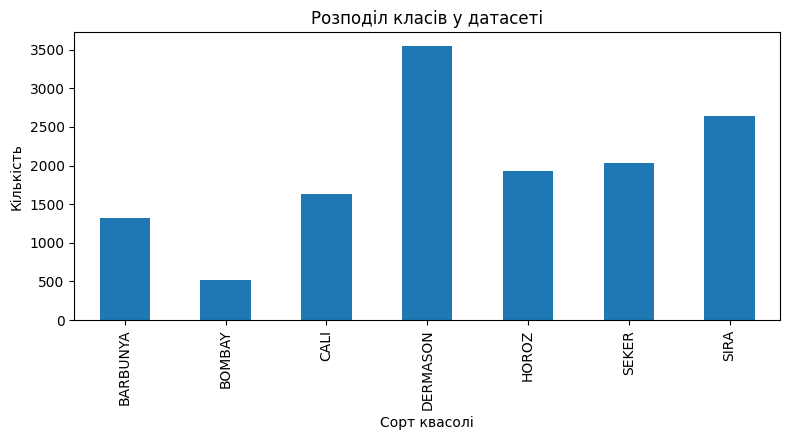

Висновок: діаграма показує чисельність сортів; нерівномірність враховуємо через macro-F1 та balanced accuracy.


In [2]:
print('Типи ознак:')
display(df.dtypes.to_frame('Тип'))
print('Пропущені значення:')
display(df.isna().sum().to_frame('Пропуски'))
print('Дублікати:', df.duplicated().sum())
display(df.describe().T)
class_counts = df['Class'].value_counts().sort_index()
display(class_counts.to_frame('Кількість'))
class_counts.plot(kind='bar', title='Розподіл класів у датасеті')
plt.xlabel('Сорт квасолі'); plt.ylabel('Кількість'); plt.tight_layout(); plt.show()
print('Висновок: діаграма показує чисельність сортів; нерівномірність враховуємо через macro-F1 та balanced accuracy.')

In [ ]:
# Я підсумувала EDA за фактичними таблицями та графіком.
print(f"Я дослідила {len(df)} записів, {len(df.columns)-1} ознак та {df['Class'].nunique()} класів.")
print(f"Я знайшла {int(df.isna().sum().sum())} пропущених значень і {int(df.duplicated().sum())} повних дублікатів.")
print(f"На діаграмі найбільше прикладів класу {class_counts.idxmax()} ({class_counts.max()}), а найменше — {class_counts.idxmin()} ({class_counts.min()}).")
print('Причина нерівномірності — різна представленість сортів у наборі даних. Через це я використовую macro-F1 та balanced accuracy, а не тільки accuracy.')
print('Таблиця описової статистики показує різні масштаби числових ознак, тому перед градієнтним спуском я застосувала стандартизацію.')


In [3]:
# Я додатково оцінила дисбаланс класів, щоб пояснити вибір метрик.
most_common, least_common = int(class_counts.max()), int(class_counts.min())
print(f'Я побачила, що найбільший клас має {most_common} записів, найменший — {least_common}.')
print(f'Співвідношення найбільшого та найменшого класів: {most_common/least_common:.2f}.')
print('Тому я оцінюю не лише accuracy, а й macro-F1 та balanced accuracy.')

Я побачила, що найбільший клас має 3546 записів, найменший — 522.
Співвідношення найбільшого та найменшого класів: 6.79.
Тому я оцінюю не лише accuracy, а й macro-F1 та balanced accuracy.


### Розбиття до відбору ознак і масштабування
Виділяю **Global Test = 20%**, **Global Validation = 15%** від усього набору, **FL Train Pool = 65%**. Обидві серверні вибірки стратифіковані. Жоден клієнт не отримує Validation або Test. Це запобігає **Data Leakage** — витоку інформації з даних оцінювання у процес навчання.

In [4]:
# Я визначила числові характеристики та цільова змінна
raw_features = df.drop(columns=['Class']).select_dtypes(include=np.number).columns.tolist()
clean = df[raw_features + ['Class']].copy().drop_duplicates()
# Пропуски ознак я заповнила медіанами, розрахованими тільки на Train.
clean = clean.dropna(subset=['Class'])
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(clean['Class'])
X_all = clean[raw_features].reset_index(drop=True)
all_idx = np.arange(len(clean))
idx_pool_val, idx_test = train_test_split(all_idx, test_size=0.20, stratify=y_all, random_state=SEED)
idx_pool, idx_val = train_test_split(idx_pool_val, test_size=0.15/0.80,
                                    stratify=y_all[idx_pool_val], random_state=SEED)
X_pool_raw, X_val_raw, X_test_raw = X_all.iloc[idx_pool].copy(), X_all.iloc[idx_val].copy(), X_all.iloc[idx_test].copy()
y_pool, y_val, y_test = y_all[idx_pool], y_all[idx_val], y_all[idx_test]
print('FL Train Pool:', len(y_pool), 'Global Validation:', len(y_val), 'Global Test:', len(y_test))
assert len(set(idx_pool)&set(idx_val)) == len(set(idx_pool)&set(idx_test)) == len(set(idx_val)&set(idx_test)) == 0
print('Перевірка: множини не перетинаються.')

FL Train Pool: 8802 Global Validation: 2032 Global Test: 2709
Перевірка: множини не перетинаються.


,Множина,Кількість,"Частка, %"
0,FL Train Pool,8802,64.99
1,Global Validation,2032,15.00
2,Global Test,2709,20.00


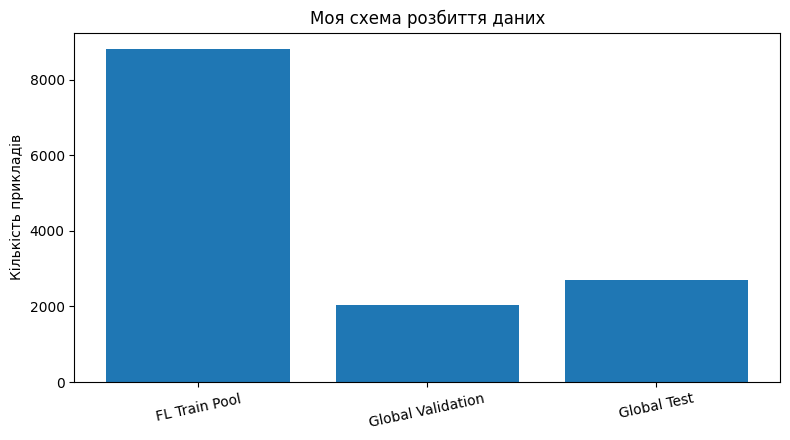

Я виділила тренувальну частину для клієнтів, а Validation і Test залишила для незалежної оцінки.


In [5]:
# Я побудувала схему розбиття та перевірила частки вибірок.
split_table = pd.DataFrame({'Множина': ['FL Train Pool', 'Global Validation', 'Global Test'],
                            'Кількість': [len(y_pool), len(y_val), len(y_test)]})
split_table['Частка, %'] = (split_table['Кількість'] / len(y_all) * 100).round(2)
display(split_table)
plt.bar(split_table['Множина'], split_table['Кількість'])
plt.title('Моя схема розбиття даних'); plt.ylabel('Кількість прикладів')
plt.xticks(rotation=12); plt.tight_layout(); plt.show()
print('Я виділила тренувальну частину для клієнтів, а Validation і Test залишила для незалежної оцінки.')

In [ ]:
# Я пояснила схему розбиття даних та її вплив на подальше навчання.
for _, r in split_table.iterrows():
    print(f"Я виділила {r['Множина']}: {int(r['Кількість'])} прикладів ({r['Частка, %']:.2f}%).")
print('Ці три частини не перетинаються: Train потрібен для навчання, Validation — для вибору параметрів, Test — тільки для фінальної перевірки.')
print('Таке розбиття запобігає Data Leakage та дозволяє чесно порівняти моделі.')


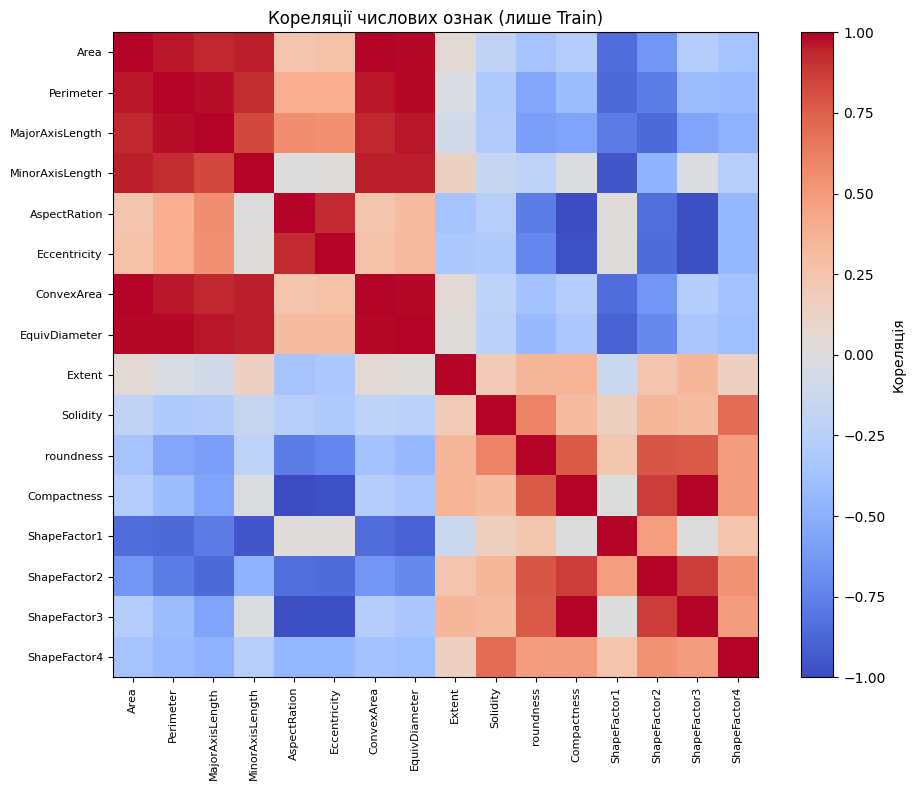

,Ознака,F-оцінка,p-value
6,ConvexArea,18931.840777,0.000000e+00
0,Area,18929.535433,0.000000e+00
7,EquivDiameter,16493.310952,0.000000e+00
1,Perimeter,15853.992048,0.000000e+00
3,MinorAxisLength,14559.766487,0.000000e+00
2,MajorAxisLength,14023.508767,0.000000e+00
13,ShapeFactor2,7921.004377,0.000000e+00
12,ShapeFactor1,7850.792259,0.000000e+00
4,AspectRation,6654.926795,0.000000e+00
11,Compactness,6504.391404,0.000000e+00


Відібрані ознаки: ['ConvexArea', 'Perimeter', 'MinorAxisLength', 'MajorAxisLength', 'ShapeFactor2', 'ShapeFactor1', 'AspectRation', 'ShapeFactor3', 'roundness', 'ShapeFactor4', 'Solidity', 'Extent']
Висновок: відбір виконано без тестових даних; майже дубльовані ознаки вилучено, щоб зменшити мультиколінеарність.


In [6]:
# Кореляції та відбір ознак я обчислила виключно на FL Train Pool.
medians = X_pool_raw.median()
X_pool_filled = X_pool_raw.fillna(medians)
X_val_filled = X_val_raw.fillna(medians)
X_test_filled = X_test_raw.fillna(medians)
cor = X_pool_filled.corr()
plt.figure(figsize=(10, 8)); plt.imshow(cor, vmin=-1, vmax=1, cmap='coolwarm')
plt.xticks(range(len(cor)), cor.columns, rotation=90, fontsize=8)
plt.yticks(range(len(cor)), cor.columns, fontsize=8)
plt.colorbar(label='Кореляція'); plt.title('Кореляції числових ознак (лише Train)')
plt.tight_layout(); plt.show()
# Я використала ANOVA F, яка вимірює зв'язок числових ознак із категоріальною ціллю.
f_scores, p_values = f_classif(X_pool_filled, y_pool)
rank = pd.DataFrame({'Ознака': raw_features, 'F-оцінка': f_scores, 'p-value': p_values}).sort_values('F-оцінка', ascending=False)
display(rank)
# Я прибрала лише майже дубльовані ознаки (|r| >= 0.98); серед пари залишаємо з більшою F-оцінкою.
selected = []
for feature in rank['Ознака']:
    if all(abs(cor.loc[feature, prev]) < 0.98 for prev in selected):
        selected.append(feature)
print('Відібрані ознаки:', selected)
print('Висновок: відбір виконано без тестових даних; майже дубльовані ознаки вилучено, щоб зменшити мультиколінеарність.')

In [7]:
# Я показала, наскільки сильними залишилися кореляції між відібраними ознаками.
selected_cor = cor.loc[selected, selected].abs().copy()
np.fill_diagonal(selected_cor.values, 0)
max_corr = selected_cor.to_numpy().max()
print(f'Максимальна абсолютна парна кореляція між відібраними ознаками: {max_corr:.3f}.')
print('Я врахувала, що парна кореляція не може повністю виключити мультиколінеарність.')
print('Оскільки Class — категорія, для зв’язку ознак із ціллю я використала ANOVA F, а не звичайну кореляцію Пірсона.')
display(rank.head(8))

Максимальна абсолютна парна кореляція між відібраними ознаками: 0.979.
Я врахувала, що парна кореляція не може повністю виключити мультиколінеарність.
Оскільки Class — категорія, для зв’язку ознак із ціллю я використала ANOVA F, а не звичайну кореляцію Пірсона.


,Ознака,F-оцінка,p-value
6,ConvexArea,18931.840777,0.0
0,Area,18929.535433,0.0
7,EquivDiameter,16493.310952,0.0
1,Perimeter,15853.992048,0.0
3,MinorAxisLength,14559.766487,0.0
2,MajorAxisLength,14023.508767,0.0
13,ShapeFactor2,7921.004377,0.0
12,ShapeFactor1,7850.792259,0.0


In [ ]:
# Я пояснила таблицю ANOVA та кореляційну карту.
print(f"За ANOVA F найсильніший зв’язок із Class серед ознак має {rank.iloc[0]['Ознака']} (F={rank.iloc[0]['F-оцінка']:.2f}).")
print(f'Я залишила {len(selected)} ознак; найбільша абсолютна кореляція між відібраними — {max_corr:.3f}.')
if max_corr >= 0.8:
    print('Це висока кореляція: мультиколінеарність зменшена не повністю, тому коефіцієнти моделі слід тлумачити обережно.')
else:
    print('За парними кореляціями дуже сильних зв’язків не виявлено, хоча це не виключає інших форм мультиколінеарності.')
print('Відбір за ANOVA та кореляціями я виконала тільки на Train, щоб тестова вибірка не впливала на вибір ознак.')


In [8]:
# Я обрала спрощений режим симуляції: параметри scaler обчислені на FL Train Pool,
# а не на Global Validation / Global Test (дозволено методичкою).
scaler = StandardScaler()
X_pool = scaler.fit_transform(X_pool_filled[selected]).astype(float)
X_val = scaler.transform(X_val_filled[selected]).astype(float)
X_test = scaler.transform(X_test_filled[selected]).astype(float)
C = len(label_encoder.classes_)
print('Кількість класів:', C, '| Ознак після відбору:', X_pool.shape[1])
print('Кодування: ознаки числові, тому категоріальне кодування ознак не потрібне; Class закодовано числами 0..6.')

Кількість класів: 7 | Ознак після відбору: 12
Кодування: ознаки числові, тому категоріальне кодування ознак не потрібне; Class закодовано числами 0..6.


### Мій висновок щодо підготовки даних
Я виконала заповнення пропусків, відбір ознак і стандартизацію **тільки за тренувальними даними**. Середнє та стандартне відхилення для `StandardScaler` я визначила на FL Train Pool, а до Validation і Test застосувала готове перетворення. Це спрощений, прямо дозволений методичкою варіант симуляції федеративного навчання. У цьому наборі всі вхідні ознаки числові, тому One-Hot/Ordinal/Target Encoding для них не потрібні. Цільову змінну `Class` я перетворила на номери класів, а в розрахунку градієнтів — на one-hot матрицю.

## Етап 2. Багатокласова логістична регресія на NumPy
Реалізую `Z = XW + b`, стабільний `softmax`, крос-ентропію з Ridge, градієнти та Mini-batch GD. Цикли за епохами й батчами дозволені; функція втрат і градієнти векторизовані. Зміщення `b` не регуляризую.

In [9]:
def one_hot(y, n_classes):
    return np.eye(n_classes)[np.asarray(y, dtype=int)]

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

class NumpySoftmaxRegression:
    def __init__(self, n_features, n_classes, reg=0.0):
        self.W = np.zeros((n_features, n_classes), dtype=float)
        self.b = np.zeros(n_classes, dtype=float)
        self.reg = float(reg)

    def get_params(self):
        return self.W.copy(), self.b.copy()

    def set_params(self, params):
        self.W = params[0].copy()
        self.b = params[1].copy()

    def predict_proba(self, X):
        return softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def loss(self, X, y):
        p = self.predict_proba(X)
        ce = -np.mean(np.log(np.clip(p[np.arange(len(y)), y], 1e-15, 1.0)))
        return ce + (self.reg / 2) * np.sum(self.W ** 2)

    def gradients(self, X, y):
        m = len(y)
        error = self.predict_proba(X) - one_hot(y, self.W.shape[1])
        dW = (X.T @ error) / m + self.reg * self.W
        db = np.mean(error, axis=0)
        return dW, db

    def fit(self, X, y, lr=0.1, epochs=40, batch_size=128, seed=42,
            X_monitor=None, y_monitor=None):
        rng = np.random.default_rng(seed)
        history = {'train_loss': [], 'val_loss': []}
        for epoch in range(epochs):
            for batch in np.array_split(rng.permutation(len(y)),
                                        max(1, int(np.ceil(len(y) / batch_size)))):
                dW, db = self.gradients(X[batch], y[batch])
                self.W -= lr * dW
                self.b -= lr * db
            history['train_loss'].append(self.loss(X, y))
            if X_monitor is not None:
                history['val_loss'].append(self.loss(X_monitor, y_monitor))
        return history

# Я перевірила softmax та форми градієнтів
_demo = NumpySoftmaxRegression(X_pool.shape[1], C, reg=0.001)
assert np.allclose(_demo.predict_proba(X_pool[:5]).sum(axis=1), 1)
assert _demo.gradients(X_pool[:5], y_pool[:5])[0].shape == _demo.W.shape
print('Перевірки softmax і градієнтів пройдено.')

Перевірки softmax і градієнтів пройдено.


### Як я реалізувала модель
Я самостійно написала модель у NumPy. Спочатку обчислюю `Z = XW + b`, а потім застосовую `softmax`, щоб отримати ймовірності семи класів. Для числової стійкості я віднімаю найбільше значення в кожному рядку. Далі обчислюю **крос-ентропію + Ridge (L2)**, а градієнти знаходжу матричними операціями без циклів за прикладами. Я оновлюю `W` і `b` за Mini-batch Gradient Descent; `b` не регуляризую. Цикли використала лише для епох та батчів, як дозволено методичкою.

## Етап 3. Централізована базова модель
Порівнюю гіперпараметри **тільки за Global Validation**: швидкість навчання, розмір батчу та Ridge-регуляризацію. Global Test не використовую для вибору параметрів.

,lr,batch_size,ridge,accuracy,macro-F1,balanced accuracy,log-loss
1,0.10,128,0.001,0.939961,0.949412,0.947108,0.218932
3,0.20,256,0.001,0.939961,0.949412,0.947108,0.218687
0,0.05,128,0.000,0.937992,0.947425,0.945085,0.227568
2,0.10,64,0.010,0.934547,0.943157,0.939565,0.316356


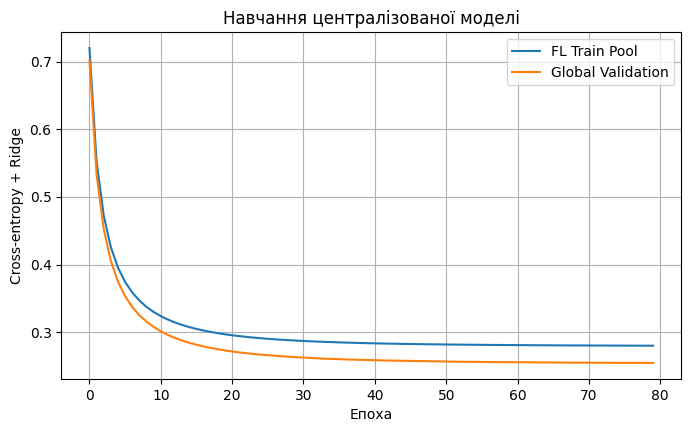

Обрано за Validation: {'lr': 0.1, 'batch_size': 128, 'ridge': 0.001}
Висновок: криві показують, як зменшується функція втрат; конфігурацію обрано за macro-F1 на Validation.


In [10]:
def metrics(model, X, y):
    prob = model.predict_proba(X)
    pred = np.argmax(prob, axis=1)
    return {'accuracy': accuracy_score(y, pred),
            'macro-F1': f1_score(y, pred, average='macro', zero_division=0),
            'balanced accuracy': balanced_accuracy_score(y, pred),
            'log-loss': log_loss(y, prob, labels=np.arange(C))}

configs = [(0.05, 128, 0.0), (0.1, 128, 0.001), (0.1, 64, 0.01), (0.2, 256, 0.001)]
search_rows = []
for lr, bs, reg in configs:
    model = NumpySoftmaxRegression(X_pool.shape[1], C, reg)
    hist = model.fit(X_pool, y_pool, lr=lr, batch_size=bs, epochs=50,
                     X_monitor=X_val, y_monitor=y_val)
    result = metrics(model, X_val, y_val)
    search_rows.append({'lr': lr, 'batch_size': bs, 'ridge': reg, **result})
search_table = pd.DataFrame(search_rows).sort_values('macro-F1', ascending=False)
display(search_table)
best = search_table.iloc[0]
best_lr, best_bs, best_reg = float(best.lr), int(best.batch_size), float(best.ridge)
central = NumpySoftmaxRegression(X_pool.shape[1], C, best_reg)
central_history = central.fit(X_pool, y_pool, lr=best_lr, batch_size=best_bs, epochs=80,
                              X_monitor=X_val, y_monitor=y_val)
plt.plot(central_history['train_loss'], label='FL Train Pool')
plt.plot(central_history['val_loss'], label='Global Validation')
plt.xlabel('Епоха'); plt.ylabel('Cross-entropy + Ridge'); plt.title('Навчання централізованої моделі')
plt.legend(); plt.grid(True); plt.show()
print('Обрано за Validation:', {'lr': best_lr, 'batch_size': best_bs, 'ridge': best_reg})
print('Висновок: криві показують, як зменшується функція втрат; конфігурацію обрано за macro-F1 на Validation.')

In [ ]:
# Я пояснила таблицю підбору параметрів та графік функції втрат.
print(f'Я порівняла {len(search_table)} конфігурації за macro-F1 на Global Validation.')
print(f'Найкраща конфігурація: lr={best_lr:g}, batch_size={best_bs}, Ridge={best_reg:g}; macro-F1={best["macro-F1"]:.4f}.')
tr0, tr1 = central_history['train_loss'][0], central_history['train_loss'][-1]
va0, va1 = central_history['val_loss'][0], central_history['val_loss'][-1]
print(f'На графіку Train loss змінився з {tr0:.4f} до {tr1:.4f}, а Validation loss — з {va0:.4f} до {va1:.4f}.')
print('Зміна втрат відображає, як градієнтний спуск коригує ваги; різниця між Train і Validation допомагає помітити можливе перенавчання.')
print('Для вибору швидкості навчання, батчу й Ridge я використала лише Validation, не Test.')


In [11]:
# Я оцінила реальну зміну втрат та результат підбору параметрів.
first_loss, last_loss = central_history['val_loss'][0], central_history['val_loss'][-1]
print(f'Я побачила зміну Validation loss: {first_loss:.4f} → {last_loss:.4f}.')
print(f'Я перевірила {len(configs)} конфігурації lr, batch_size та Ridge і обрала їх за macro-F1 на Validation.')
print('Ridge=0 означає модель без регуляризації, а додатне Ridge — зі штрафом за великі ваги.')
print('Якщо Validation loss починає зростати, це може вказувати на перенавчання.')

Я побачила зміну Validation loss: 0.7024 → 0.2546.
Я перевірила 4 конфігурації lr, batch_size та Ridge і обрала їх за macro-F1 на Validation.
Ridge=0 означає модель без регуляризації, а додатне Ridge — зі штрафом за великі ваги.
Якщо Validation loss починає зростати, це може вказувати на перенавчання.


,accuracy,macro-F1,balanced accuracy,log-loss
Централізована модель — Global Test,0.915836,0.927354,0.925761,0.244094


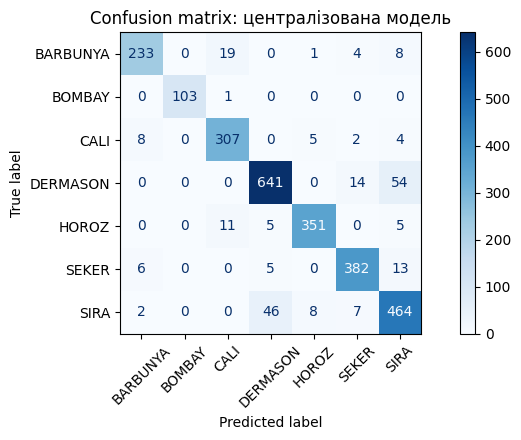

Висновок: діагональ матриці — правильні прогнози, інші комірки — плутанина між сортами.


In [12]:
central_test = metrics(central, X_test, y_test)
display(pd.DataFrame([central_test], index=['Централізована модель — Global Test']))
ConfusionMatrixDisplay.from_predictions(y_test, central.predict(X_test),
                                        display_labels=label_encoder.classes_, xticks_rotation=45, cmap='Blues')
plt.title('Confusion matrix: централізована модель'); plt.tight_layout(); plt.show()
print('Висновок: діагональ матриці — правильні прогнози, інші комірки — плутанина між сортами.')

In [13]:
# Я пояснила, які класи модель плутає найчастіше.
cm_central = confusion_matrix(y_test, central.predict(X_test), labels=np.arange(C))
errors = cm_central.copy(); np.fill_diagonal(errors, 0)
row, col = np.unravel_index(np.argmax(errors), errors.shape)
print(f'Я отримала accuracy={central_test["accuracy"]:.4f}, macro-F1={central_test["macro-F1"]:.4f}, '
      f'balanced accuracy={central_test["balanced accuracy"]:.4f}, log-loss={central_test["log-loss"]:.4f}.')
print(f'Найбільше помилок між різними класами: {label_encoder.classes_[row]} → {label_encoder.classes_[col]} ({errors[row,col]}).')
print('Я використовую macro-F1 і balanced accuracy, тому що класи можуть бути нерівномірними.')

Я отримала accuracy=0.9158, macro-F1=0.9274, balanced accuracy=0.9258, log-loss=0.2441.
Найбільше помилок між різними класами: DERMASON → SIRA (54).
Я використовую macro-F1 і balanced accuracy, тому що класи можуть бути нерівномірними.


In [ ]:
# Я уточнила висновок до confusion matrix.
correct = int(np.trace(cm_central)); total = int(cm_central.sum())
print(f'Я правильно класифікувала {correct} із {total} тестових прикладів централізованою моделлю.')
print(f'Найчастіше модель плутала {label_encoder.classes_[row]} із {label_encoder.classes_[col]}: {errors[row,col]} випадків.')
print('Позадіагональні значення виникають, коли фізичні характеристики різних сортів схожі.')
print('Я врахувала ці помилки при порівнянні моделей через macro-F1 та balanced accuracy.')


## Етап 4. Розподіл між клієнтами та сервером
**Сервер** зберігає Global Validation, Global Test і глобальні ваги. **Клієнти** отримують лише власні частини FL Train Pool; сирі дані не передаються серверу. Для симуляції всі масиви технічно містяться в одному ноутбуці, але функції локального навчання отримують лише свої частини.

Порівнюю IID та Non-IID через розподіл Діріхле. Кожен приклад має потрапити рівно одному клієнту; перевіряю це програмно.

,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA,Всього
Клієнт 1,172,68,212,461,242,264,343,1762
Клієнт 2,172,68,212,461,242,264,343,1762
Клієнт 3,172,68,212,461,242,263,343,1761
Клієнт 4,172,68,212,461,242,263,342,1760
Клієнт 5,171,68,211,461,241,263,342,1757


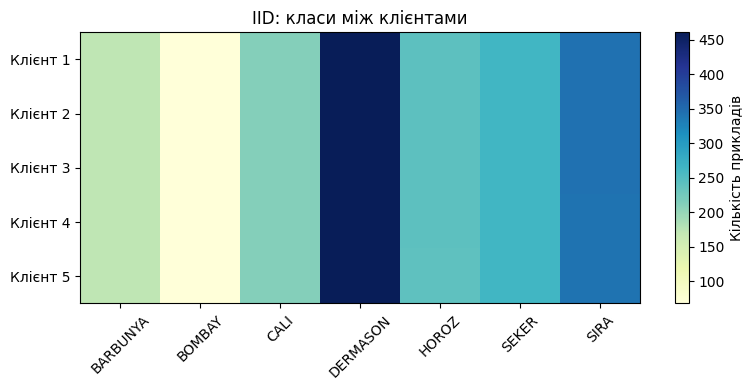

Висновок: кожен приклад належить одному клієнту; темніші комірки означають більше записів відповідного класу.


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA,Всього
Клієнт 1,40,0,2,0,1,413,18,474
Клієнт 2,714,24,91,91,165,789,786,2660
Клієнт 3,4,216,451,585,913,1,11,2181
Клієнт 4,100,0,503,816,19,7,9,1454
Клієнт 5,1,100,12,813,111,107,889,2033


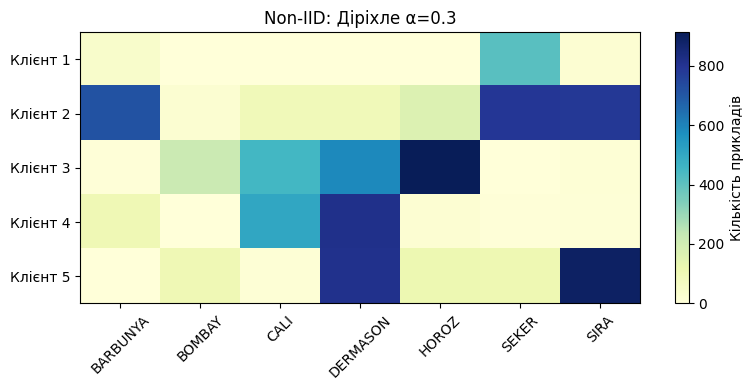

Висновок: кожен приклад належить одному клієнту; темніші комірки означають більше записів відповідного класу.


In [14]:
K = 5

def make_iid_partition(y, k=K, seed=SEED):
    rng = np.random.default_rng(seed)
    groups = [[] for _ in range(k)]
    # Я стратифіковано розподілила кожен клас, щоб пропорції були близькими.
    for c in np.unique(y):
        ids = rng.permutation(np.flatnonzero(y == c))
        for j, part in enumerate(np.array_split(ids, k)):
            groups[j].extend(part.tolist())
    return [np.array(g, dtype=int) for g in groups]

def make_dirichlet_partition(y, alpha, k=K, seed=SEED, min_size=10):
    rng = np.random.default_rng(seed)
    for attempt in range(200):
        groups = [[] for _ in range(k)]
        for c in np.unique(y):
            ids = rng.permutation(np.flatnonzero(y == c))
            portions = rng.dirichlet(np.full(k, alpha))
            sizes = rng.multinomial(len(ids), portions)
            for j, part in enumerate(np.split(ids, np.cumsum(sizes)[:-1])):
                groups[j].extend(part.tolist())
        if min(map(len, groups)) >= min_size:
            return [np.array(g, dtype=int) for g in groups]
    raise RuntimeError('Не вдалося створити розподіл з достатньою кількістю записів.')

def check_partition(groups, n):
    joined = np.concatenate(groups)
    assert len(joined) == n and len(np.unique(joined)) == n
    assert np.array_equal(np.sort(joined), np.arange(n))
    assert min(map(len, groups)) >= 10

def partition_counts(groups, y):
    return pd.DataFrame([np.bincount(y[g], minlength=C) for g in groups],
                        index=[f'Клієнт {i+1}' for i in range(len(groups))],
                        columns=label_encoder.classes_)

def show_partition(groups, title):
    check_partition(groups, len(y_pool))
    counts = partition_counts(groups, y_pool)
    display(counts.assign(Всього=counts.sum(axis=1)))
    plt.figure(figsize=(8, 4))
    plt.imshow(counts, aspect='auto', cmap='YlGnBu')
    plt.xticks(range(C), counts.columns, rotation=45)
    plt.yticks(range(len(groups)), counts.index)
    plt.colorbar(label='Кількість прикладів')
    plt.title(title); plt.tight_layout(); plt.show()
    print('Висновок: кожен приклад належить одному клієнту; темніші комірки означають більше записів відповідного класу.')

iid_groups = make_iid_partition(y_pool)
non_iid_groups = make_dirichlet_partition(y_pool, alpha=0.3)
show_partition(iid_groups, 'IID: класи між клієнтами')
show_partition(non_iid_groups, 'Non-IID: Діріхле α=0.3')

In [15]:
# Я перевірила кількість прикладів та різницю між IID і Non-IID.
for title, groups in [('IID', iid_groups), ('Non-IID α=0.3', non_iid_groups)]:
    sizes = np.array([len(g) for g in groups])
    print(f'{title}: я розподілила {sizes.sum()} прикладів між {len(groups)} клієнтами; '
          f'мінімум={sizes.min()}, максимум={sizes.max()}.')
    assert sizes.min() >= 10
print('Я переконалася, що кожен запис належить лише одному клієнту, а сервер не навчається на їхніх сирих даних.')

IID: я розподілила 8802 прикладів між 5 клієнтами; мінімум=1757, максимум=1762.
Non-IID α=0.3: я розподілила 8802 прикладів між 5 клієнтами; мінімум=474, максимум=2660.
Я переконалася, що кожен запис належить лише одному клієнту, а сервер не навчається на їхніх сирих даних.


In [ ]:
# Я зробила окремі висновки до двох теплових карт і таблиць розподілу.
for title, groups in [('IID', iid_groups), ('Non-IID α=0.3', non_iid_groups)]:
    t = partition_counts(groups, y_pool)
    totals = t.sum(axis=1)
    proportions = t.div(totals, axis=0)
    variation = float(proportions.std(axis=0).mean())
    print(f'{title}: я отримала від {totals.min()} до {totals.max()} прикладів на клієнта; середній розкид часток класів між клієнтами = {variation:.3f}.')
print('На IID тепловій карті пропорції класів між клієнтами близькі, а на Non-IID вони різняться через розподіл Діріхле.')
print('Такі відмінності можуть спрямовувати локальні оновлення в різні боки, тому я порівняла якість FedAvg для обох сценаріїв.')


## Етап 5. Федеративне навчання FedAvg
Кожного раунду сервер передає однакові глобальні ваги клієнтам. Клієнти навчаються **лише на локальних даних** і повертають ваги `W`, `b`. Сервер обчислює **зважене середнє** за кількістю прикладів, не отримуючи самих записів.

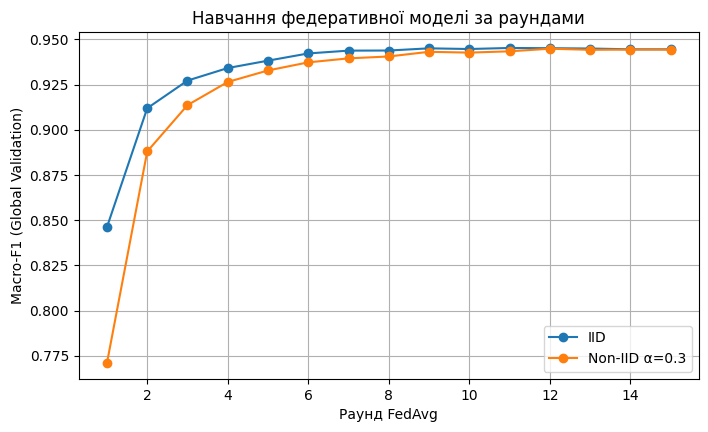

Висновок: графік показує зміну якості після агрегації; за Non-IID локальні оновлення можуть більше суперечити одне одному.


In [16]:
def fedavg(params, sizes):
    weights = np.asarray(sizes, dtype=float) / np.sum(sizes)
    W = sum(a * p[0] for a, p in zip(weights, params))
    b = sum(a * p[1] for a, p in zip(weights, params))
    return W, b

def federated_train(groups, rounds=15, local_epochs=5, lr=None, batch_size=None, reg=None, seed=SEED):
    lr = best_lr if lr is None else lr
    batch_size = best_bs if batch_size is None else batch_size
    reg = best_reg if reg is None else reg
    global_model = NumpySoftmaxRegression(X_pool.shape[1], C, reg)
    history = []
    for t in range(rounds):
        updates, sizes = [], []
        for k, ids in enumerate(groups):
            client = NumpySoftmaxRegression(X_pool.shape[1], C, reg)
            client.set_params(global_model.get_params())
            client.fit(X_pool[ids], y_pool[ids], lr=lr, batch_size=batch_size,
                       epochs=local_epochs, seed=seed + t*100 + k)
            updates.append(client.get_params())
            sizes.append(len(ids))
        global_model.set_params(fedavg(updates, sizes))
        m = metrics(global_model, X_val, y_val)
        history.append({'round': t+1, **m, 'val_loss': global_model.loss(X_val, y_val)})
    return global_model, pd.DataFrame(history)

fed_iid, hist_iid = federated_train(iid_groups)
fed_non_iid, hist_non_iid = federated_train(non_iid_groups)
plt.plot(hist_iid['round'], hist_iid['macro-F1'], marker='o', label='IID')
plt.plot(hist_non_iid['round'], hist_non_iid['macro-F1'], marker='o', label='Non-IID α=0.3')
plt.xlabel('Раунд FedAvg'); plt.ylabel('Macro-F1 (Global Validation)')
plt.title('Навчання федеративної моделі за раундами'); plt.legend(); plt.grid(True); plt.show()
print('Висновок: графік показує зміну якості після агрегації; за Non-IID локальні оновлення можуть більше суперечити одне одному.')

In [17]:
# Я порівняла реальні значення на початку і наприкінці федеративного навчання.
for label, hist in [('IID', hist_iid), ('Non-IID α=0.3', hist_non_iid)]:
    print(f'Я отримала для {label}: macro-F1 на Validation {hist["macro-F1"].iloc[0]:.4f} → '
          f'{hist["macro-F1"].iloc[-1]:.4f}; останній log-loss={hist["log-loss"].iloc[-1]:.4f}.')
print('Я агрегувала і матрицю W, і зміщення b, зважуючи оновлення за кількістю записів клієнтів.')

Я отримала для IID: macro-F1 на Validation 0.8462 → 0.9445; останній log-loss=0.2601.
Я отримала для Non-IID α=0.3: macro-F1 на Validation 0.7710 → 0.9443; останній log-loss=0.2735.
Я агрегувала і матрицю W, і зміщення b, зважуючи оновлення за кількістю записів клієнтів.


In [ ]:
# Я пояснила графік навчання за раундами й вибір сценарію.
fi, fn = float(hist_iid['macro-F1'].iloc[-1]), float(hist_non_iid['macro-F1'].iloc[-1])
print(f'Наприкінці раундів я отримала macro-F1 IID={fi:.4f} і Non-IID={fn:.4f} на Validation.')
print('Графік показує зміну якості після кожної агрегації; відмінності між кривими пов’язані з неоднаковими розподілами локальних даних.')
print('За цим порівнянням кращим із двох сценаріїв на Validation є ' + ('IID.' if fi >= fn else 'Non-IID.'))
print('Я не використовую Global Test для вибору сценарію чи налаштування кількості раундів.')


## Етап 6. Порівняння та обов’язкові експерименти
Порівнюю локальні, глобальні та централізовану моделі. **Global Test використовую лише для фінального звіту**, не для підбору параметрів. Для експериментів обираю значення за Validation і лише після завершення експериментів рахую тестові метрики.

,alpha,macro-F1 Validation,min прикладів
0,5.0,0.946293,1163
1,1.0,0.944944,1032
2,0.3,0.944318,474


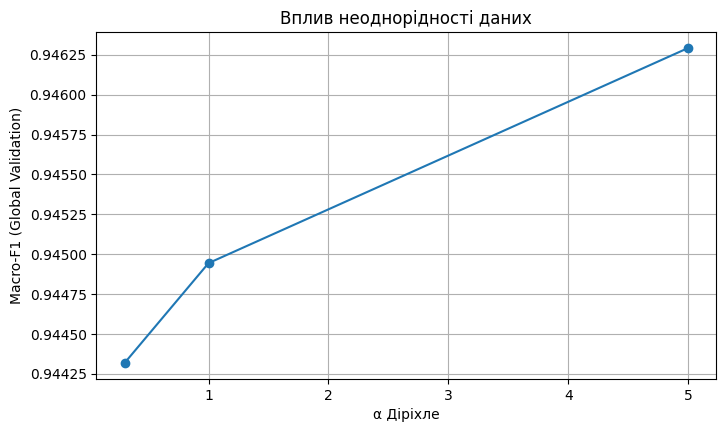

Висновок: менше α означає більшу неоднорідність. Її вплив на якість визначається за наведеними результатами, а не припускається наперед.


In [18]:
# Я виконала експеримент 1: вплив неоднорідності α = 5, 1, 0.3
alpha_models = {}
alpha_histories = {}
alpha_rows = []
for alpha in [5.0, 1.0, 0.3]:
    groups = make_dirichlet_partition(y_pool, alpha=alpha, seed=SEED)
    check_partition(groups, len(y_pool))
    model, history = federated_train(groups, rounds=15, local_epochs=5)
    alpha_models[alpha] = model
    alpha_histories[alpha] = history
    alpha_rows.append({'alpha': alpha, 'macro-F1 Validation': metrics(model, X_val, y_val)['macro-F1'],
                       'min прикладів': min(map(len, groups))})
alpha_table = pd.DataFrame(alpha_rows)
display(alpha_table)
plt.plot(alpha_table['alpha'], alpha_table['macro-F1 Validation'], marker='o')
plt.xlabel('α Діріхле'); plt.ylabel('Macro-F1 (Global Validation)')
plt.title('Вплив неоднорідності даних'); plt.grid(True); plt.show()
print('Висновок: менше α означає більшу неоднорідність. Її вплив на якість визначається за наведеними результатами, а не припускається наперед.')

In [19]:
# Я описала закономірність за фактично отриманими значеннями, а не наперед.
worst_alpha = alpha_table.loc[alpha_table['macro-F1 Validation'].idxmin()]
best_alpha_row = alpha_table.loc[alpha_table['macro-F1 Validation'].idxmax()]
print(f'Я побачила: найкращий macro-F1={best_alpha_row["macro-F1 Validation"]:.4f} при α={best_alpha_row["alpha"]:g}; '
      f'найменший={worst_alpha["macro-F1 Validation"]:.4f} при α={worst_alpha["alpha"]:g}.')
print('Я пояснюю це тим, що менше α створює різні пропорції класів у клієнтів, але ефект не обов’язково монотонний.')

Я побачила: найкращий macro-F1=0.9463 при α=5; найменший=0.9443 при α=0.3.
Я пояснюю це тим, що менше α створює різні пропорції класів у клієнтів, але ефект не обов’язково монотонний.


In [ ]:
# Я пояснила вплив α для таблиці та графіка.
vals = alpha_table.set_index('alpha')['macro-F1 Validation']
print('Я порівняла α=5, α=1 та α=0.3 на одній Global Validation.')
print(f'Різниця між найбільшим і найменшим macro-F1 становить {vals.max()-vals.min():.4f}.')
print('Менше α зазвичай створює сильнішу неоднорідність класів, що може посилити суперечність локальних оновлень.')
print(f'Серед перевірених значень я обрала б α={best_alpha_row["alpha"]:g} за macro-F1 на Validation, але α тут є параметром експериментального розподілу, а не властивістю реальних клієнтів.')


,E,macro-F1 Validation
0,1,0.935254
1,5,0.944318
2,10,0.946983


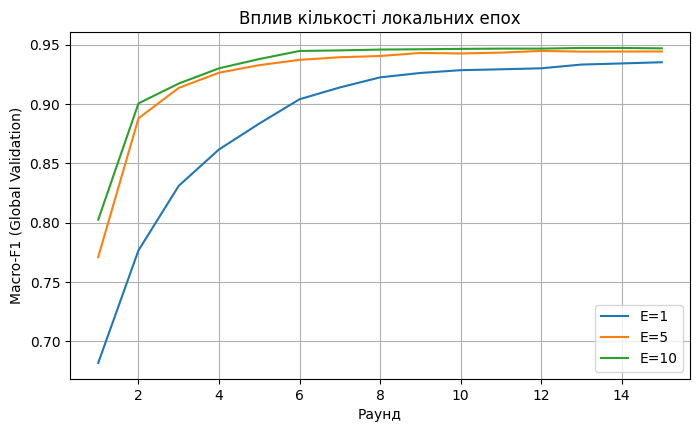

Висновок: більше локальних епох означає більше локальних оновлень, але на Non-IID даних може посилювати client drift.


In [20]:
# Я виконала експеримент 2: E = 1, 5, 10 на однаковому Non-IID розподілі α=0.3
fixed_groups = make_dirichlet_partition(y_pool, alpha=0.3, seed=SEED)
epoch_models, epoch_histories, epoch_rows = {}, {}, []
for E in [1, 5, 10]:
    model, history = federated_train(fixed_groups, rounds=15, local_epochs=E)
    epoch_models[E], epoch_histories[E] = model, history
    epoch_rows.append({'E': E, 'macro-F1 Validation': metrics(model, X_val, y_val)['macro-F1']})
epoch_table = pd.DataFrame(epoch_rows)
display(epoch_table)
for E, history in epoch_histories.items():
    plt.plot(history['round'], history['macro-F1'], label=f'E={E}')
plt.xlabel('Раунд'); plt.ylabel('Macro-F1 (Global Validation)')
plt.title('Вплив кількості локальних епох'); plt.legend(); plt.grid(True); plt.show()
print('Висновок: більше локальних епох означає більше локальних оновлень, але на Non-IID даних може посилювати client drift.')

In [21]:
# Я порівняла якість при E=1, 5 та 10 і зафіксувала найкраще значення.
epoch_winner = epoch_table.loc[epoch_table['macro-F1 Validation'].idxmax()]
print(f'Я побачила найкращий macro-F1={epoch_winner["macro-F1 Validation"]:.4f} при E={int(epoch_winner["E"])}.')
print('Я перевірила, що збільшення локальних епох не гарантує покращення через client drift.')

Я побачила найкращий macro-F1=0.9470 при E=10.
Я перевірила, що збільшення локальних епох не гарантує покращення через client drift.


In [ ]:
# Я пояснила таблицю та графік експерименту з локальними епохами.
for _, r in epoch_table.iterrows():
    print(f'При E={int(r["E"])} я отримала macro-F1={r["macro-F1 Validation"]:.4f} на Validation.')
print(f'Найкращим у цьому експерименті було E={int(epoch_winner["E"])}.')
print('Більше локальних епох дає клієнту більше оновлень між агрегаціями, але на Non-IID даних може посилити client drift.')
print('Тому кількість локальних епох я порівнюю за Global Validation, а не вибираю автоматично найбільше E.')


Найкраща федеративна конфігурація за Validation: FedAvg E=10


,accuracy,macro-F1,balanced accuracy,log-loss
Модель,,,,
Централізована,0.9158,0.9274,0.9258,0.2441
Глобальна IID,0.9133,0.9250,0.9237,0.2914
Глобальна Non-IID,0.9133,0.9248,0.9226,0.3035
FedAvg E=10 (обрана),0.9155,0.9266,0.9238,0.2762
Локальна IID 1,0.9099,0.9215,0.9189,0.2944
Локальна IID 2,0.9125,0.9247,0.9239,0.2897
Локальна IID 3,0.9121,0.9235,0.9228,0.2924
Локальна IID 4,0.9151,0.9259,0.9245,0.2888
Локальна IID 5,0.9110,0.9227,0.9213,0.2892


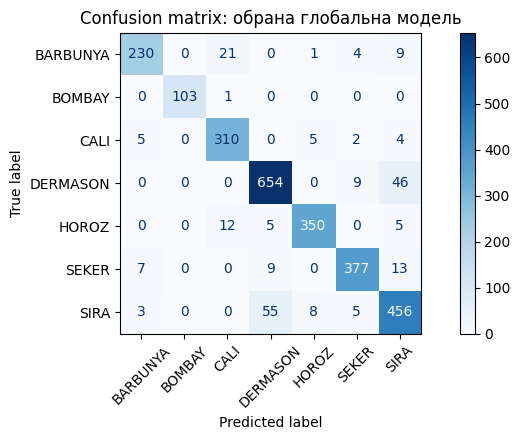

Висновок: таблиця порівнює моделі на однаковому Global Test. Вища macro-F1 та balanced accuracy означають кращий баланс між класами; нижчий log-loss — кращі ймовірності.


In [22]:
# Я зробила фінальний вибір федеративної моделі — лише за Validation.
candidates = {'FedAvg IID': fed_iid, 'FedAvg Non-IID α=0.3': fed_non_iid}
candidates.update({f'FedAvg α={a:g}': m for a, m in alpha_models.items()})
candidates.update({f'FedAvg E={e}': m for e, m in epoch_models.items()})
chosen_name = max(candidates, key=lambda name: metrics(candidates[name], X_val, y_val)['macro-F1'])
chosen_model = candidates[chosen_name]
print('Найкраща федеративна конфігурація за Validation:', chosen_name)

# Я навчила локальні моделі: навчання тільки на даних одного клієнта (IID).
local_models = []
for k, ids in enumerate(iid_groups):
    local = NumpySoftmaxRegression(X_pool.shape[1], C, best_reg)
    local.fit(X_pool[ids], y_pool[ids], lr=best_lr, batch_size=best_bs, epochs=80, seed=SEED+k)
    local_models.append(local)

comparison = []
for name, model in [('Централізована', central), ('Глобальна IID', fed_iid),
                    ('Глобальна Non-IID', fed_non_iid), (chosen_name + ' (обрана)', chosen_model)]:
    comparison.append({'Модель': name, **metrics(model, X_test, y_test)})
for i, model in enumerate(local_models):
    comparison.append({'Модель': f'Локальна IID {i+1}', **metrics(model, X_test, y_test)})
comparison_df = pd.DataFrame(comparison).set_index('Модель')
display(comparison_df.round(4))
ConfusionMatrixDisplay.from_predictions(y_test, chosen_model.predict(X_test),
                                        display_labels=label_encoder.classes_,
                                        xticks_rotation=45, cmap='Blues')
plt.title('Confusion matrix: обрана глобальна модель'); plt.tight_layout(); plt.show()
print('Висновок: таблиця порівнює моделі на однаковому Global Test. Вища macro-F1 та balanced accuracy означають кращий баланс між класами; нижчий log-loss — кращі ймовірності.')

In [23]:
# Я проаналізувала таблицю моделей на одному й тому самому Global Test.
leader = comparison_df['macro-F1'].idxmax()
print(f'Я отримала найвищий macro-F1 на Global Test у моделі «{leader}»: '
      f'{comparison_df.loc[leader, "macro-F1"]:.4f}.')
print(f'Я порівняла централізовану та обрану глобальну моделі: '
      f'{comparison_df.loc["Централізована", "macro-F1"]:.4f} і '
      f'{comparison_df.loc[chosen_name + " (обрана)", "macro-F1"]:.4f}.')
print('Я розумію, що Test використано лише для остаточного порівняння, а не для вибору гіперпараметрів.')

Я отримала найвищий macro-F1 на Global Test у моделі «Централізована»: 0.9274.
Я порівняла централізовану та обрану глобальну моделі: 0.9274 і 0.9266.
Я розумію, що Test використано лише для остаточного порівняння, а не для вибору гіперпараметрів.


In [ ]:
# Я пояснила таблицю порівняння та confusion matrix глобальної моделі.
selected_key = chosen_name + ' (обрана)'
cf1 = float(comparison_df.loc['Централізована', 'macro-F1'])
gf1 = float(comparison_df.loc[selected_key, 'macro-F1'])
print(f'На Global Test централізована модель отримала macro-F1={cf1:.4f}, а обрана глобальна — {gf1:.4f}; різниця={gf1-cf1:+.4f}.')
print(f'Найкращий macro-F1 серед наведених у таблиці моделей має {leader}.')
cm_global = confusion_matrix(y_test, chosen_model.predict(X_test), labels=np.arange(C))
err_global = cm_global.copy(); np.fill_diagonal(err_global, 0)
r, c = np.unravel_index(np.argmax(err_global), err_global.shape)
print(f'На матриці помилок глобальної моделі найбільша позадіагональна комірка: {label_encoder.classes_[r]} → {label_encoder.classes_[c]} ({err_global[r,c]}).')
print('Помилки можуть виникати через подібність сортів та неоднорідність локальних вибірок.')
print('За цією таблицею я оцінюю переваги й обмеження моделей, але не переналаштовую їх на Test.')


### Пояснення експериментів
**Non-IID:** у клієнтів різні пропорції сортів, тому локальні градієнти можуть спрямовувати моделі в різні боки. Через це глобальна модель іноді поступається централізованій або окремій локальній моделі (особливо на даних, схожих на дані цього клієнта). Але це не обов'язково відбувається в кожному запуску.

**Client drift:** якщо клієнти навчаються багато локальних епох на неоднорідних даних, їхні ваги сильніше відхиляються від спільної моделі. Тому збільшення `E` не завжди покращує FedAvg.

**FedAvg із вагами:** клієнт із 2000 прикладів має впливати більше, ніж клієнт зі 100, бо представляє більше навчальних даних. Просте середнє надмірно підсилює малих клієнтів.

In [24]:
# Я сформувала підсумковий висновок на основі реально отриманих метрик.
central_f1 = comparison_df.loc['Централізована', 'macro-F1']
chosen_f1 = metrics(chosen_model, X_test, y_test)['macro-F1']
alpha_best = alpha_table.loc[alpha_table['macro-F1 Validation'].idxmax(), 'alpha']
e_best = epoch_table.loc[epoch_table['macro-F1 Validation'].idxmax(), 'E']
display(Markdown(f"""### Загальний висновок
У практичній роботі я проаналізувала Dry Bean Dataset, розділила дані на FL Train Pool, Global Validation і Global Test та реалізувала багатокласову логістичну регресію засобами NumPy. Для класифікації використала softmax, крос-ентропію, Ridge-регуляризацію та Mini-batch Gradient Descent.

Також я змоделювала федеративне навчання FedAvg із п'ятьма клієнтами, IID і Non-IID розподілами та зваженим об'єднанням ваг. На Global Test централізована модель отримала **macro-F1 = {central_f1:.4f}**, а обрана за Validation федеративна модель (**{chosen_name}**) — **macro-F1 = {chosen_f1:.4f}**.

У дослідженні неоднорідності найкраще значення α на Validation: **{alpha_best:g}**; у дослідженні локальних епох найкраще E: **{int(e_best)}**. Отже, якість федеративної моделі залежить від розподілу класів між клієнтами та кількості локальних кроків. Я обрала гіперпараметри тільки за Global Validation, а Global Test залишила для підсумкової оцінки. Висновки про вплив α та E зробила за отриманими графіками й таблицями. Для мене це показало, що неоднорідність даних та кількість локальних епох можуть змінювати якість спільної моделі."""))

### Загальний висновок
У практичній роботі я проаналізувала Dry Bean Dataset, розділила дані на FL Train Pool, Global Validation і Global Test та реалізувала багатокласову логістичну регресію засобами NumPy. Для класифікації використала softmax, крос-ентропію, Ridge-регуляризацію та Mini-batch Gradient Descent.

Також я змоделювала федеративне навчання FedAvg із п'ятьма клієнтами, IID і Non-IID розподілами та зваженим об'єднанням ваг. На Global Test централізована модель отримала **macro-F1 = 0.9274**, а обрана за Validation федеративна модель (**FedAvg E=10**) — **macro-F1 = 0.9266**.

У дослідженні неоднорідності найкраще значення α на Validation: **5**; у дослідженні локальних епох найкраще E: **10**. Отже, якість федеративної моделі залежить від розподілу класів між клієнтами та кількості локальних кроків. Я обрала гіперпараметри тільки за Global Validation, а Global Test залишила для підсумкової оцінки. Висновки про вплив α та E зробила за отриманими графіками й таблицями. Для мене це показало, що неоднорідність даних та кількість локальних епох можуть змінювати якість спільної моделі.

## Теоретичні питання до захисту (17 відповідей)

**1. Чому для багатокласової класифікації використовують softmax?**  
Softmax перетворює оцінки моделі на ймовірності класів, які в сумі дорівнюють 1.

**2. Чому крос-ентропія підходить для логістичної регресії?**  
Вона штрафує модель, коли та дає низьку ймовірність правильному класу, і відповідає максимізації правдоподібності.

**3. Чим Ridge відрізняється від Lasso?**  
Ridge (L2) зменшує ваги, а Lasso (L1) може зробити деякі ваги рівними нулю.

**4. Чому зміщення b не регуляризують?**  
Зміщення не є вагою окремої ознаки, тому зазвичай штрафують тільки W.

**5. Що таке Data Leakage?**  
Це витік інформації з Validation або Test у процес навчання чи підготовки моделі.

**6. Чому Test не використовують для підбору параметрів?**  
Інакше модель підлаштовується під Test, і фінальна оцінка перестає бути незалежною.

**7. Чому scaler навчають тільки на Train?**  
Щоб середні та стандартні відхилення з Validation/Test не впливали на модель.

**8. Що таке федеративне навчання?**  
Клієнти навчають модель на своїх даних, а сервер об'єднує оновлення без збору сирих даних.

**9. Чому сервер не отримує сирі дані клієнтів?**  
Щоб зберігати дані локально та зменшити потребу передавати приватну інформацію.

**10. Чому FedAvg зважує за кількістю прикладів?**  
Щоб більші локальні набори даних мали пропорційно більший вплив на спільну модель.

**11. Що буде без зважування?**  
Маленький клієнт матиме такий самий вплив, як великий, і результат може зміститися.

**12. Що таке Non-IID?**  
Це коли розподіли даних у клієнтів відрізняються, наприклад за частками класів.

**13. Чому Non-IID може погіршувати навчання?**  
Клієнти навчаються на різних класах, тому їхні оновлення можуть суперечити одне одному.

**14. Що таке client drift?**  
Це відхилення локальних моделей від глобальної під час навчання на різних даних.

**15. Як впливають локальні епохи?**  
Більше епох дає більше локального навчання, але на Non-IID може посилювати client drift.

**16. Чи може глобальна модель бути гіршою за централізовану?**  
Так, через неоднорідність даних, обмеження раундів і відмінності локальних оновлень.

**17. Які метрики корисні при дисбалансі класів?**  
Macro-F1 і balanced accuracy враховують якість за різними класами; також аналізують confusion matrix та log-loss.

### Моя перевірка виконання вимог методички
Я перевірила всі обов’язкові етапи:

| Вимога | Де я її виконала |
|---|---|
| EDA, типи даних, пропуски, статистики, розподіл класів | Етап 1 |
| Відбір ознак і перевірка кореляцій без Test | Етап 1 |
| Стратифіковані FL Train Pool, Global Validation, Global Test | Етап 1 |
| Кодування цілі та стандартизація тільки на Train | Етап 1 |
| Власні softmax, predict, loss, gradients, Mini-batch GD, Ridge | Етап 2 |
| Підбір learning rate, batch size, Ridge на Validation | Етап 3 |
| Accuracy, macro-F1, balanced accuracy, log-loss, confusion matrix | Етапи 3 і 6 |
| Ролі сервера та клієнтів, IID і Non-IID, перевірка розподілу | Етап 4 |
| Власна зважена агрегація FedAvg та графік за раундами | Етап 5 |
| Порівняння локальних, глобальних і централізованої моделей | Етап 6 |
| Обов’язкові експерименти α=5, 1, 0.3 та E=1, 5, 10 | Етап 6 |
| Усі 17 теоретичних відповідей | Розділ «Теоретичні питання» |
| Загальний висновок | Наприкінці Етапу 6 |

Я також перевірила, що **додатковий експеримент з K або персоналізацією є необов’язковим**. Я не використовувала готову `LogisticRegression` чи `SGDClassifier` для основної моделі.

**Важливе уточнення:** цей Notebook є **симуляцією**: масиви існують в одному процесі Python. У функцію локального навчання я передаю лише індекси конкретного клієнта; для реального федеративного застосунку потрібне окреме мережеве розгортання та захист обміну вагами.

## Додатковий експеримент (опційно)
Методичка дозволяє окремо дослідити кількість клієнтів (`K=3,5,10`) або персоналізацію. Це **не обов'язкова** частина, тому основна робота завершується вище. За бажанням її можна додати пізніше.

**Підсумок:** код, графіки, таблиці та пояснення знаходяться в одному Notebook; для GitHub завантажте файл `.ipynb` після виконання всіх комірок.